# The Non-linear eigenstate solver

Just like the Schrödinger equation, the Gross-Pitaevskii equation admits states $\Psi$ satisfying the equation:

$$\left[ -\frac{\hbar^2}{2m} \nabla^2 + V(\bf{r}) + g |\psi|^2 \right] \psi(\bf{r}) = \mu \psi (\bf{r})$$


These states, as stable solutions of the time-independant Gross-Pitaveskii equation, can be seen as eigenstates. This eigenstate-like nature makes them quite important in the study of a given system. The `NLEigve` class of the eponymous submodule implements allows the computation of these eigenstates. As a children class of the `FDSolver` class, it supports coupled equations and phase-shifted boundary condition for the study of periodic systems.

In this tutorial, we will first introduce the solver by finding the mode profiles of an harmonic trap with strong interactions. Then, we will use the solver to determine the bloch band structure of a simple 1D-chain and compare the results to [[Wu2003]](https://iopscience.iop.org/article/10.1088/1367-2630/5/1/104/pdf).

## Numerical implementation

To find the non-linear eigenstates of the GP equation, we use a imaginary-time-propagation scheme very similar to the one implemented in the `GroundState` class and presented in the [GettingStarted](docs\GettingStarted.ipynb) tutorial. We first find the groundstate $\ket{\psi_0}$ of the system by simple imaginary time propagation, then, we proceed iteratively to find the excited states. To do, we project at each imaginary time-step the state $\ket{\psi_n}$ on a subspace orthogonal to all the previously found eigenvectors $\ket{\psi_m}$, $m \in [0,n-1]$. This can be done by applying to $\ket{\psi_n}$ the projector $P_n = 1 - \sum_m \ket{\psi_m}\bra{\psi_m}$.


## Eigenstates of the harmonic potential

Let's demonstrate first the `NLEigve` class on a simple harmonic oscillator, where we chose two values for the interaction strength. For historical reasons, this solvers demands as input for the interaction 2D maps specifying the local value of the interaction constant $g(\mathbf{r})$. Of course, it is quite easy to set a uniform value for this term, which we will do in this tutorial.

In [23]:
from bloch_schrodinger.potential import Potential, create_parameter
from BECs.nleigve import NLEigve
import numpy as np
import matplotlib.pyplot as plt

# Defining some parameters
lx = 5 # box width
ly = 5 # box height
nx = 50 # resolution along x
ny = 50 # resolution along y

hbar = 1
m = 1

omx = 5 # trap strength along x
omy = 5.5 # trap strength along y, it's always better to have a slight anisotropy

harmonic = Potential( # The potential object
    [[lx, 0], [0, ly]],
    resolution = (nx, ny),
    v0 = 0
)

harmonic.set(
    harmonic.x**2 * omx**2 / 2 + harmonic.y**2 * omy**2/2 # Setting the potential energy to a harmonic profile
)

g = create_parameter('g', [0, 100]) # We set two values for the interaction strength

g_map = Potential(
    [[lx, 0], [0, ly]],
    resolution = (nx, ny),
    v0 = g
)

foo = NLEigve( # The Non-linear solver is instanciated just like the FDSolver, but adding the interaction maps.
    potentials=harmonic, alphas = hbar**2/2/m, gs = g_map
)


Once instanciated, the compuation of the eigenstates is performed by calling the `solve` class method. This method supports parallelization through the `parallel` keyword argument. As the propagation is performed in part by matrix multiplication $H_0 \ket{\psi}$, it is recommanded not to use grids larger than $200 \times 200$. An implementation of the same solver with a split-step Fourier method could be added in the future to support larger grids.

In [24]:
eigva, eigve = foo.solve(
    n_eig= 3,
    population=100,
    tol = 1e-10
)

Performing 2 diagonalizations...


 50%|█████     | 1/2 [00:00<00:00,  7.47it/s]

maximum number of iterations reached, the returned state might not be converged


100%|██████████| 2/2 [00:03<00:00,  1.77s/it]


maximum number of iterations reached, the returned state might not be converged
storing the results


100%|██████████| 2/2 [00:00<00:00, 605.76it/s]


We can then visualize the eigenstates using the classic `plot_eigenvector` function from the `bloch_schrodinger` package.

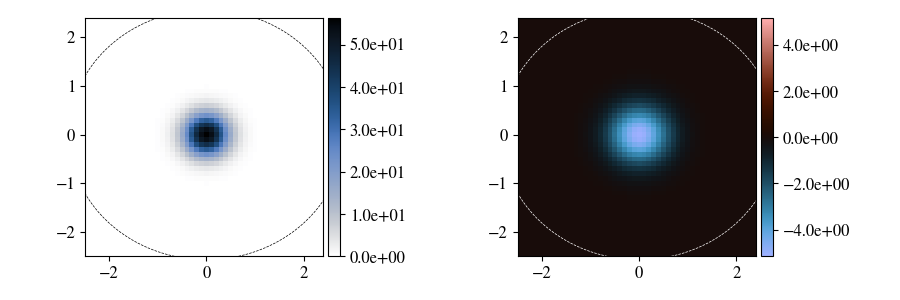

In [25]:
from bloch_schrodinger.plotting import plot_eigenvector
%matplotlib widget

plot_eigenvector(
    [[abs(eigve)**2, eigve.real]], [[harmonic, harmonic]], [['amplitude', 'real']]
)
plt.show()

As expected, the results show a broadening of the eigenstates when the repulsive interactions are added. Furthermore, the transition between each lobe of opposite phase becomes much sharper, a behavior expected in the Thomas-Fermi limit.

## Computation of non-linear Bloch bands

In this section, we will reproduce parts of the results presented in [[Wu2003]](https://iopscience.iop.org/article/10.1088/1367-2630/5/1/104/pdf), more precisely the results relative to the computation of the GP Bloch bands in a 1D chain.

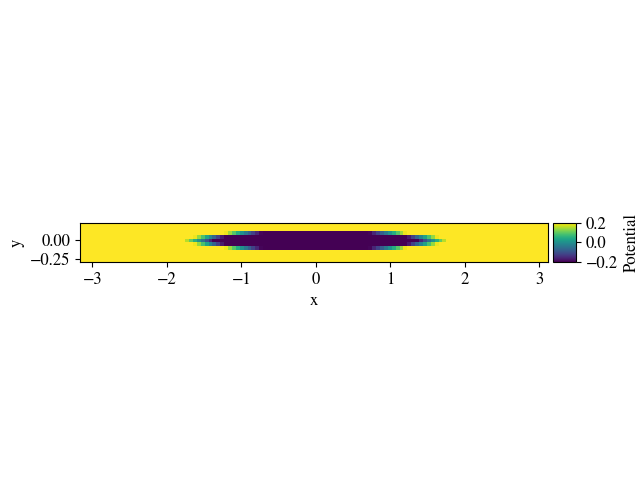

In [26]:
# Some parameters, using the notations of the article

v = 1 # Potential amplitude in natural units
c = create_parameter('c', np.linspace(0, 100, 20))
omega_y = 10 # transversal confinement

nx = 120
ny = 10


chain = Potential(
    [[2*np.pi, 0], [0,np.pi/6]],
    resolution=(nx, ny),
    v0 = 0
)

chain.add(
    chain.y**2 * omega_y**2/2
)

chain.add(
    -v*np.cos(chain.x)
)

c_map = Potential(
    [[2*np.pi, 0], [0,np.pi/3]],
    resolution=(nx, ny),
    v0 = c*v
)

chain.plot(vmin = -0.2, vmax = 0.2)
plt.show()

In [27]:
bar = NLEigve(
    potentials=chain, alphas=hbar**2/2/m, gs = c_map
)

bar.create_reciprocal_grid(
    kx = np.linspace(-1, 1, 101)
)

eigva, eigve = bar.solve(
    n_eig = 2, parallel=True, population = 1, tol = 1e-8
)

Performing 2020 diagonalizations...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 204 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 456 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 1176 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done 1582 tasks      | elapsed:   57.6s
[Parallel(n_jobs=-1)]: Done 1852 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 2020 out of 2020 | elapsed:  3.6min finished


storing the results


100%|██████████| 2020/2020 [00:03<00:00, 631.78it/s]


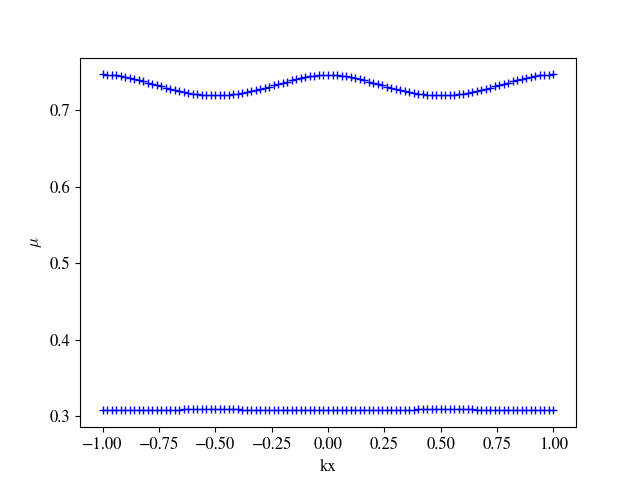

In [28]:
from bloch_schrodinger.plotting import plot_cuts, plot_eigenvector

tp = eigva.rename(r'$\mu$')

temp = {"color":"blue", "marker":"+", 'linestyle':'none'}
plot_cuts(
    tp, 'kx', groupby=['band'], linekws=[temp]
)
plt.show()